 Date: 1st August 2026

Author: Bipul Pandey

Objectives: To take through the Training of LRBM for the Population Model. 

                1. Importing the Ground Truth Population
                2. Going through entropic Partition
                3. Setting up the LRBM Framework
                4. Training the LRBM using Layered Contrastive Divergence
                5. Generating New Samples from LRBM
                6. Showing Statistics Preservation
                7. Showing LRBM Energy Statistics
        

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
from tqdm import tqdm

import sys
sys.path.append("../Scripts/")
from Hierarchy_construction import *
from LRBM_Compressed_Potts import *
from Frequency_Calculators import *


print("="*30 ,"Options:", "="*30)
print("     1 : Toy model of evolution")
print("     2: Images- MNIST")
print("     3: Sentences - Animal Simple Wikipedia")
print("     4: Sentences - Alice in Wonderland")
print("     5: Protein - Chorismate Mutase")
print("="*70)

============================== Options: ==============================
     1 : Toy model of evolution
     2: Images- MNIST
     3: Sentences - Animal Simple Wikipedia
     4: Sentences - Alice in Wonderland
     5: Protein - Chorismate Mutase


In [2]:
def Energy_Given_Model(Ohe_Array, Model):
    num_part = Model.num_of_partitions
    Energy_by_scale ={}
    Total_Energy = np.zeros(len(Ohe_Array))
    for p in range(0, num_part):
        Data_self, Data_interact = Model.Data_Partition(Ohe_Array, p)
        Weight_part = Model.Weights[p]
        Bias_part = Model.Bias[p]
        Energy_p = Model.Energy_Array_given_partition_easy(Ohe_Array, p)
        name_p = f"Scale_{p+1}_Energy"
        Energy_by_scale[name_p] = Energy_p
        Total_Energy+=Energy_p
    Energy_by_scale["Total_Energy"] = Total_Energy

    return Energy_by_scale

In [3]:
Experiment = 1


Experiment = int(Experiment)

if Experiment ==1:
    print("Population Toy Model")
    Data_loc = "../../Training_Data/Toy_Model_Evolution/Training_Data_Final_5000_Ground_Truth_Population.csv"
    Gen_loc = "../../Results/Generated_Data/Toy_Model_Evolution/LRBM_Generated_Population.csv"
    Model_loc = "../../Model_Parameters/Toy_Model_Evolution_LRBM_Toy/"
    Compress_Alphabets = False

elif Experiment ==2:
    print("MNIST")
    Data_loc =  "../../Training_Data/Images_MNIST/Training_Data_MNIST_Binarized_500_images.csv"
    Gen_loc = "../../Results/Generated_Data/Images_MNIST/LRBM_Generated_MNIST_Images.csv"
    Model_loc ="../../Model_Parameters/Images_LRBM_MNIST/"
    Compress_Alphabets = False

elif Experiment == 3:
    print("Sentences- Animal:Simple Wikipedia")
    Data_loc = "../../Training_Data/Sentences_Wiki/Training_Data_Wiki_1589_Tokenized_Sentences.csv"
    Gen_loc = "../../Results/Generated_Data/Sentences_Wiki/LRBM_Generated_Wiki_Sentences.csv"
    Model_loc =  "../../Model_Parameters/Sentences_LRBM_Wiki/"
    Compress_Alphabets = True

elif Experiment ==4:
    print("Sentences - Alice in Wonderland")
    Data_loc ="../../Training_Data/Sentences_Alice/Training_Data_Alice_716_Tokenized_Sentences.csv"
    Gen_loc = "../../Results/Generated_Data/Sentences_Alice/LRBM_Generated_Alice_Sentences.csv"
    Model_loc =  "../../Model_Parameters/Sentences_LRBM_Alice/"
    Compress_Alphabets = True

else:
    Experiment == 5
    print("Protein : Chorismate Mutase")
    Data_loc = "../../Training_Data/Protien_Chorismate_Mutase/Training_Data_Natural_1130_Chorismate_Mutase.csv"
    Gen_loc = "../../Results/Generated_Data/Protein_Chorismate_Mutase/LRBM_Generated_Chorismate_Mutase.csv"
    Model_loc =  "../../Model_Parameters/Proteins_LRBM_CM/"
    Compress_Alphabets = False


Population Toy Model


In [9]:
## Loading Training Data: ---
Training_Dataset = pd.read_csv(Data_loc)

Columns = Training_Dataset.columns
Postion_Columns=[]
for c in Columns:
    if c[0:3] == "Pos":
        Postion_Columns.append(c)
print("Number of Positions=", len(Postion_Columns))
Compact_Training_Dataset = np.array(Training_Dataset[Postion_Columns])
##------------

## ----Loading Scales ----
Entropic_Partition_Map = np.loadtxt(Model_loc+"Entropic_Scales_Partition_Map.txt")

Number of Positions= 16


_______
### 1. Finding the Number of Partition:

In [5]:
### 
## In the beginning we can give some random number as number of clusters
Starting_num_scale = 5
Minimum_features_in_each_scale = 2

Hierarchy = Hierarchy_Analysis(Compact_Data=Compact_Training_Dataset, Number_of_clusters= Starting_num_scale, Min_partition_size=Minimum_features_in_each_scale)

Any Entropic Scale with less than 2 features will be combined with the nearest scale.


In [6]:
Smallest_num_scales_tested = 2
Largest_num_scales_tested = 8
Proportion_of_Population_used = 0.4
Num_Trials = 100
Overlap_window = 1


GVF_Array, num_scales, Overlap_Partition_Map = Hierarchy.Jenks_GVF_Bootstrap(Smallest_num_scales_tested,
                                                      Largest_num_scales_tested,
                                                      Proportion_of_Population_used,
                                                      Num_Trials,
                                                      Overlap_window)

(7, 100)


100%|██████████| 100/100 [00:36<00:00,  2.76it/s]

Overlap condition met.
Appropriate number of clusters from Elbow.  = 4
Appropriate number of clusters from Overlap = 4
Returning- dictionary containing GVF Bootstraps for various cluster numbers and appropriate cluster numbers


We can also use the KDE Scale Finder. Infact, for MNIST and sentences, KDE is better. 

We show its implementation in a separate notebook.
Here we will proceed with the entropic partition found.

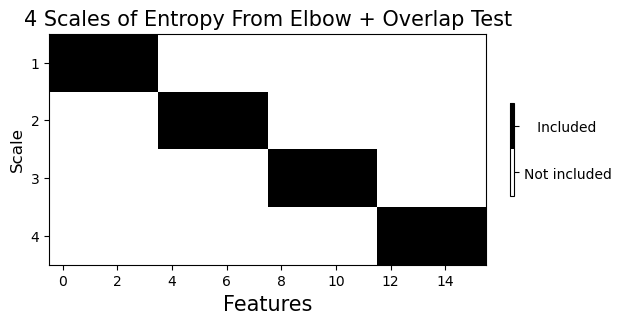

In [7]:
plt.figure(figsize=(6,3))
img = plt.imshow(Overlap_Partition_Map, cmap = 'binary', aspect='auto')
plt.title(f"{len(Overlap_Partition_Map)} Scales of Entropy From Elbow + Overlap Test", fontsize = 15)
plt.xlabel("Features", fontsize = 15)
plt.ylabel("Scale", fontsize = 12)
plt.yticks(range(0, len(Overlap_Partition_Map)), range(1, len(Overlap_Partition_Map)+1))
cbar = plt.colorbar(img, boundaries=[-0.5, 0.5, 1.5], ticks=[0, 1], fraction = 0.01)
cbar.set_ticklabels(['Not included', '   Included'])

plt.show()

_______
### 2. Model Training:

In [27]:
##
Use_Map_above = True
if Use_Map_above:
    print("We will use the entropic partition map we found above")
    Entropic_Partition_Map = Overlap_Partition_Map
else:
    print("We will use the entropic partition map computed in the paper")
    Entropic_Partition_Map

We will use the entropic partition map we found above


In [28]:
LRBM = Compressed_LRBM(Compact_Training_Dataset, Entropic_Partition_Map, compressed=Compress_Alphabets, extra_character="*zz")

Number of Partitions Set= 4
..Setting Partition Map..
Number of partitions = 4
semi-warm start. Matching only the frequencies
semi-warm start. Matching only the frequencies


In [29]:
### Lets look at the current state of the model:

### Test sample generation
num_samples = 200
num_iter = 400
Fin_state_begin =[]
Seed_begin = []

for s in tqdm(range(0, num_samples)):
    #f, r_s = LRBM.Gibbs_Sampling_Through_Layers_given_Flip_Fraction(num_iter, 0 )
    f, r_s = LRBM.Gibbs_Sampling_through_Layers(num_iter, 0)
    Fin_state_begin.append(f)
    Seed_begin.append(r_s)


100%|██████████| 200/200 [00:10<00:00, 19.22it/s]


## Frequency Analysis for the initial state of the model

In [103]:
### ------ For natural or Ground Truth (GT) Data ------

## since triplet calculations are slow, I set it to false here
## set it to true if you want to do them
Perform_triplet_calculation = True
### ----------------------------------------------------



Dataset_1 = Compact_Training_Dataset
# Find the unique alphabets in Training Data
Alphabets = Alphabet_list(Dataset_1)
Num_alphabets = len(Alphabets)

Dataset_2 = One_hot_decoder_Array(np.array(Fin_state_begin), Alphabets)

print("Number of unique alphabets=", Num_alphabets)

### One hot encoding Training and generated data

Ohe_dataset_1 = One_hot_encoder_Array(Dataset_1, Alphabets)
Ohe_dataset_2= One_hot_encoder_Array(Dataset_2, Alphabets)

### Integer representation

Int_repr_dataset_1 = Integer_encode_Array(Dataset_1, Alphabets)
Int_repr_dataset_2 = Integer_encode_Array(Dataset_2, Alphabets)

##-----

Sing_Freq_GT= Singlet_Frequency(Ohe_dataset_1, Num_alphabets)
PW_Freq_GT,_ = Pairwise_Frequency(Ohe_dataset_1, Num_alphabets)
PW_Corr_GT,_ = Pairwise_Correlation(Ohe_dataset_1, Num_alphabets)

if Perform_triplet_calculation:
    Trip_Corr_GT =Triplet_Correlation(Int_repr_dataset_1, Ohe_dataset_1, Num_alphabets)
print("Naturals Done")

### ------ For LRBM Data ------
Sing_Freq_LRBM= Singlet_Frequency(Ohe_dataset_2, Num_alphabets)
PW_Freq_LRBM,_ = Pairwise_Frequency(Ohe_dataset_2, Num_alphabets)
PW_Corr_LRBM,_ = Pairwise_Correlation(Ohe_dataset_2, Num_alphabets)
if Perform_triplet_calculation:
    Trip_Corr_LRBM =Triplet_Correlation(Int_repr_dataset_2, Ohe_dataset_2, Num_alphabets)
print("LRBM Done")

Number of unique alphabets= 4
Naturals Done
LRBM Done


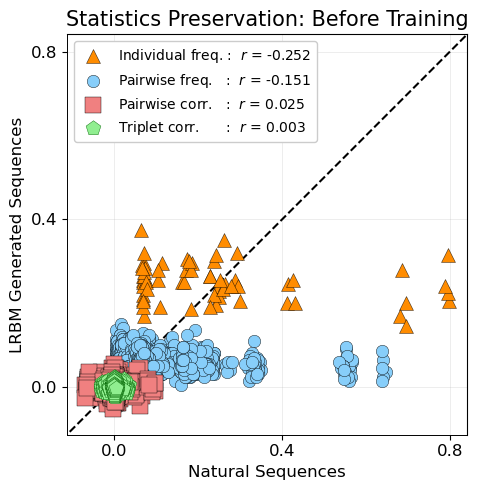

In [104]:

# ---- Data -------------

individual_nat  = np.array(Sing_Freq_GT)
individual_syn  = np.array(Sing_Freq_LRBM)

pairwise_freq_nat  = np.array(PW_Freq_GT)
pairwise_freq_syn  = np.array(PW_Freq_LRBM)

pairwise_corr_nat  = np.array(PW_Corr_GT)
pairwise_corr_syn  = np.array(PW_Corr_LRBM)


if Perform_triplet_calculation:
    triplet_nat  = np.array(Trip_Corr_GT)
    triplet_syn  = np.array(Trip_Corr_LRBM)

# ── Plot config ───────────────────────────────────────────────────────

if Perform_triplet_calculation:
    datasets = [
        dict(nat=individual_nat,   syn=individual_syn,
            label='Individual freq. ',  color='darkorange', marker='^', size=100, edgecolor = "black", zorder = 3),
        dict(nat=pairwise_freq_nat, syn=pairwise_freq_syn,
            label='Pairwise freq.   ',    color='lightskyblue', marker='o', size=80, edgecolor = "black", zorder = 2),
        dict(nat=pairwise_corr_nat, syn=pairwise_corr_syn,
            label='Pairwise corr.   ',    color='lightcoral', marker='s', size=125, edgecolor = "black", zorder = 3),
        dict(nat=triplet_nat,       syn=triplet_syn,
            label='Triplet corr.      ',     color='lightgreen', marker='p', size=125, edgecolor = "darkgreen", zorder =3),
    ]

else:
    datasets = [
        dict(nat=individual_nat,   syn=individual_syn,
            label='Individual freq. ',  color='darkorange', marker='^', size=30, edgecolor = "black", zorder = 3),
        dict(nat=pairwise_freq_nat, syn=pairwise_freq_syn,
            label='Pairwise freq.   ',    color='lightskyblue', marker='o', size=30, edgecolor = "black", zorder = 2),
        dict(nat=pairwise_corr_nat, syn=pairwise_corr_syn,
            label='Pairwise corr.   ',    color='lightcoral', marker='s', size=65, edgecolor = "black", zorder = 3)
    ]


for d in datasets:
    r2   = r2_score(d['nat'], d['syn'])
    rmse = np.sqrt(np.mean((d['nat'] - d['syn']) ** 2))
    pson_r= pearsonr(d['nat'], d['syn'])[0]
    d['r2']= r2
    d['rmse']= rmse
    d['pearson_r'] = pson_r

# ── Figure ────────────────────────────────────────────────────────────
fig0, ax = plt.subplots(figsize=(5, 5))

# Determine global axis limits across all datasets
all_nat = np.concatenate([d['nat'] for d in datasets])
all_syn = np.concatenate([d['syn'] for d in datasets])
lo = min(all_nat.min(), all_syn.min())
hi = max(all_nat.max(), all_syn.max())
pad = (hi - lo) * 0.05
lo, hi = lo - pad, hi + pad



# Scatter each statistic + annotation
annotation_y = 0.97  # tracks vertical position of text annotations
for d in datasets:
    
    pson = d['pearson_r']
    label_o = f"{d['label']}:  $r$ = {pson :.3f}"
    ax.scatter(d['nat'], d['syn'],
               color=d['color'], marker=d['marker'],
               s=d['size'], alpha=1, linewidths=0.3,
               edgecolors=d['edgecolor'], zorder=d['zorder'], label=label_o)

    annotation_y -= 0.07

# ── Axes formatting ───────────────────────────────────────────────────
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect('equal')
ax.set_xlabel('Natural Sequences', fontsize=12)
ax.set_ylabel('LRBM Generated Sequences', fontsize=12)
ax.set_title('Statistics Preservation: Before Training', fontsize=15)


ax.tick_params(labelsize=10)
ax.grid(linewidth=0.4, alpha=0.4, zorder=0)

ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(True)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(0.7)

# Legend (shapes/colors only, no duplicating the text annotations)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, fontsize=10, frameon=True,
          framealpha=1, edgecolor='#cccccc',
          loc='upper left')
#plt.xlim(-0.2,1)
#plt.ylim(-0.2,1)
# 1:1 diagonal
ax.plot([-0.2, 1], [-0.2, 1], color='black', linewidth=1.5,
        linestyle='--', zorder=1)


ax.set_xticks([0,0.4,0.8])
ax.set_yticks([0,0.4,0.8])
ax.tick_params(labelsize = 12)

plt.tight_layout()


save = False
Fig_path = "../../Plots/"
if save == True:

    plt.savefig(Fig_path+'statistics_preservation_LRBM.pdf', transparent= True, dpi=300, bbox_inches='tight')
    plt.savefig(Fig_path+'statistics_preservation_LRBM.png', dpi=300, bbox_inches='tight')
plt.show()

### Now we train the model using Persistent Contrastive Divergence with adaptive learning scheme:

    --> we won't train it completely. (that takes a while)
    --> But we will show that it is actually being trained.
    --> We will show this through drop of Pseudo log likelihood error and sample statistics


In [32]:
Partition_to_train = 0

#### First lets give the parameters for the parallel tempering chains.
num_chains =6
max_temp = 3
min_temp =0.5

type=1
Temp_steps = LRBM.PT_Temperature_Steps(num_chains, max_temp=max_temp, min_temp=min_temp, type=type)
print("--- Temperatures for Parallel Tempering chains:----")
print(Temp_steps)


--- Temperatures for Parallel Tempering chains:----
[0.500001   0.60000116 0.75000137 1.00000167 1.500002   3.000001  ]


____
- The qualtity to track is the Pseudo log likelihood error rather than the reconstruction error.
- Reconstruction error is a good metric if we weren't doing parallel tempering.


In [33]:
### 

Num_epochs_to_train = 100
num_steps_for_parallel_temp = 10
learning_rate = 0.01
decay_lr = 0.8


In [34]:
Error_trace_0 = LRBM.Train_Contrastive_Divergence(LRBM.unfurled_data, Partition_to_train, Temp_steps, num_epochs=Num_epochs_to_train, num_steps=num_steps_for_parallel_temp, learning_rate=learning_rate, decay_rate=decay_lr, Adaptive=True, reset_chains=True, Bootstrap_num_steps=None, Step_Split=0.1)

100%|██████████| 174/174 [00:00<00:00, 292.39it/s]


Epoch 1/100 -- W_error=0.0914084, B_error=0.28823, Recons_error=2.1184, PLL_error=1.5364  [new best -- checkpointed]


100%|██████████| 174/174 [00:00<00:00, 424.80it/s]


Epoch 2/100 -- W_error=0.0874765, B_error=0.290817, Recons_error=2.0928, PLL_error=1.39463  [new best -- checkpointed]


100%|██████████| 174/174 [00:00<00:00, 455.68it/s]


...

Epoch 98/100 -- W_error=0.0150474, B_error=0.0327614, Recons_error=1.8762, PLL_error=0.598435


100%|██████████| 174/174 [00:00<00:00, 442.14it/s]


Epoch 99/100 -- W_error=0.0084497, B_error=0.0200913, Recons_error=1.988, PLL_error=0.617169


100%|██████████| 174/174 [00:00<00:00, 451.81it/s]

Epoch 100/100 -- W_error=0.0286485, B_error=0.0589653, Recons_error=2.2388, PLL_error=0.619652


In [35]:
Error_trace_1 = LRBM.Train_Contrastive_Divergence(LRBM.unfurled_data, 1, Temp_steps, num_epochs=Num_epochs_to_train, num_steps=num_steps_for_parallel_temp, learning_rate=learning_rate, decay_rate=decay_lr, Adaptive=True, reset_chains=True, Bootstrap_num_steps=None, Step_Split=0.1)

100%|██████████| 1562/1562 [00:06<00:00, 247.72it/s]


Epoch 1/100 -- W_error=0.0790977, B_error=0.280896, Recons_error=2.441, PLL_error=1.61528  [new best -- checkpointed]


100%|██████████| 1562/1562 [00:03<00:00, 439.88it/s]


Epoch 2/100 -- W_error=0.0716357, B_error=0.250673, Recons_error=2.5134, PLL_error=1.41813  [new best -- checkpointed]


100%|██████████| 1562/1562 [00:03<00:00, 450.71it/s]


...

Epoch 98/100 -- W_error=0.00947636, B_error=0.0234926, Recons_error=1.9968, PLL_error=0.775783


100%|██████████| 1562/1562 [00:03<00:00, 457.85it/s]


Epoch 99/100 -- W_error=0.00989066, B_error=0.0314665, Recons_error=2.0258, PLL_error=0.767732


100%|██████████| 1562/1562 [00:03<00:00, 455.49it/s]

Epoch 100/100 -- W_error=0.00577583, B_error=0.0123263, Recons_error=2.2344, PLL_error=0.787035


In [36]:
Error_trace_2 = LRBM.Train_Contrastive_Divergence(LRBM.unfurled_data, 2, Temp_steps, num_epochs=Num_epochs_to_train, num_steps=num_steps_for_parallel_temp, learning_rate=learning_rate, decay_rate=decay_lr, Adaptive=True, reset_chains=True, Bootstrap_num_steps=None, Step_Split=0.1)

100%|██████████| 2202/2202 [00:09<00:00, 224.19it/s]


Epoch 1/100 -- W_error=0.0409465, B_error=0.11346, Recons_error=2.2092, PLL_error=1.41984  [new best -- checkpointed]


100%|██████████| 2202/2202 [00:04<00:00, 456.58it/s]


Epoch 2/100 -- W_error=0.0323214, B_error=0.0690166, Recons_error=2.3768, PLL_error=1.30735  [new best -- checkpointed]


100%|██████████| 2202/2202 [00:04<00:00, 457.57it/s]


...

Epoch 98/100 -- W_error=0.00862833, B_error=0.025525, Recons_error=2.1888, PLL_error=1.0248


100%|██████████| 2202/2202 [00:04<00:00, 452.65it/s]


Epoch 99/100 -- W_error=0.00914211, B_error=0.0263941, Recons_error=2.247, PLL_error=1.00873


100%|██████████| 2202/2202 [00:04<00:00, 451.88it/s]

Epoch 100/100 -- W_error=0.0128638, B_error=0.0446343, Recons_error=2.2212, PLL_error=1.01748


In [60]:
## lets train this last one(bulky) for only 10 epochs.

Error_trace_3 = LRBM.Train_Contrastive_Divergence(LRBM.unfurled_data, 3, Temp_steps, num_epochs=10, num_steps=num_steps_for_parallel_temp, learning_rate=learning_rate, decay_rate=decay_lr, Adaptive=True, reset_chains=True, Bootstrap_num_steps=None, Step_Split=0.1)

100%|██████████| 3664/3664 [00:20<00:00, 176.79it/s]


Epoch 1/10 -- W_error=0.0172476, B_error=0.053076, Recons_error=2.2674, PLL_error=1.4118  [new best -- checkpointed]


100%|██████████| 3664/3664 [00:08<00:00, 456.74it/s]


Epoch 2/10 -- W_error=0.00842761, B_error=0.017239, Recons_error=2.2866, PLL_error=1.39441  [new best -- checkpointed]


100%|██████████| 3664/3664 [00:08<00:00, 441.97it/s]


...

Epoch 8/10 -- W_error=0.00504228, B_error=0.0150537, Recons_error=2.304, PLL_error=1.37451  [new best -- checkpointed]


100%|██████████| 3664/3664 [00:08<00:00, 437.40it/s]


Epoch 9/10 -- W_error=0.00560269, B_error=0.0187821, Recons_error=2.312, PLL_error=1.37415  [new best -- checkpointed]


100%|██████████| 3664/3664 [00:08<00:00, 435.53it/s]

Epoch 10/10 -- W_error=0.00620438, B_error=0.0213128, Recons_error=2.3156, PLL_error=1.37306  [new best -- checkpointed]


Text(0.5, 0.98, 'Pseudo-Log likelihood Errors for different layers of LRBM')

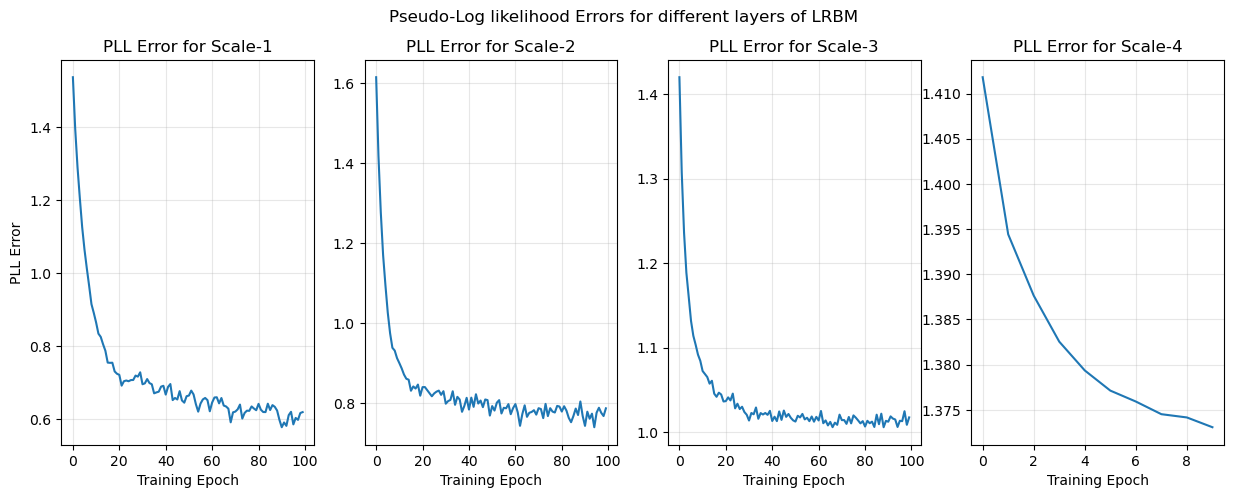

In [73]:
fig, ax = plt.subplots(1,4,figsize=(15,5))

ax[0].plot(Error_trace_0[:,3])
ax[1].plot(Error_trace_1[:,3])
ax[2].plot(Error_trace_2[:,3])
ax[3].plot(Error_trace_3[:,3])
for i in range(0,4):
    ax[i].grid(alpha = 0.3)
    ax[i].set_xlabel("Training Epoch")
    ax[i].set_title(f"PLL Error for Scale-{i+1}")
ax[0].set_ylabel("PLL Error")
fig.suptitle("Pseudo-Log likelihood Errors for different layers of LRBM")


We observe the drop in PLL. This is refined over several hundred epochs with smaller learning rates.
_____

## Sample Production from this model:

In [74]:
### Lets look at the current state of the model:

### Test sample generation
num_samples = 400
num_iter = 400
Fin_state_current =[]
Seed_current = []

for s in tqdm(range(0, num_samples)):
    #f, r_s = LRBM.Gibbs_Sampling_Through_Layers_given_Flip_Fraction(num_iter, 0 )
    f, r_s = LRBM.Gibbs_Sampling_through_Layers(num_iter, 0)
    Fin_state_current.append(f)
    Seed_current.append(r_s)


100%|██████████| 400/400 [00:22<00:00, 18.16it/s]


Text(0.5, 1.0, 'Random Seed for Current model')

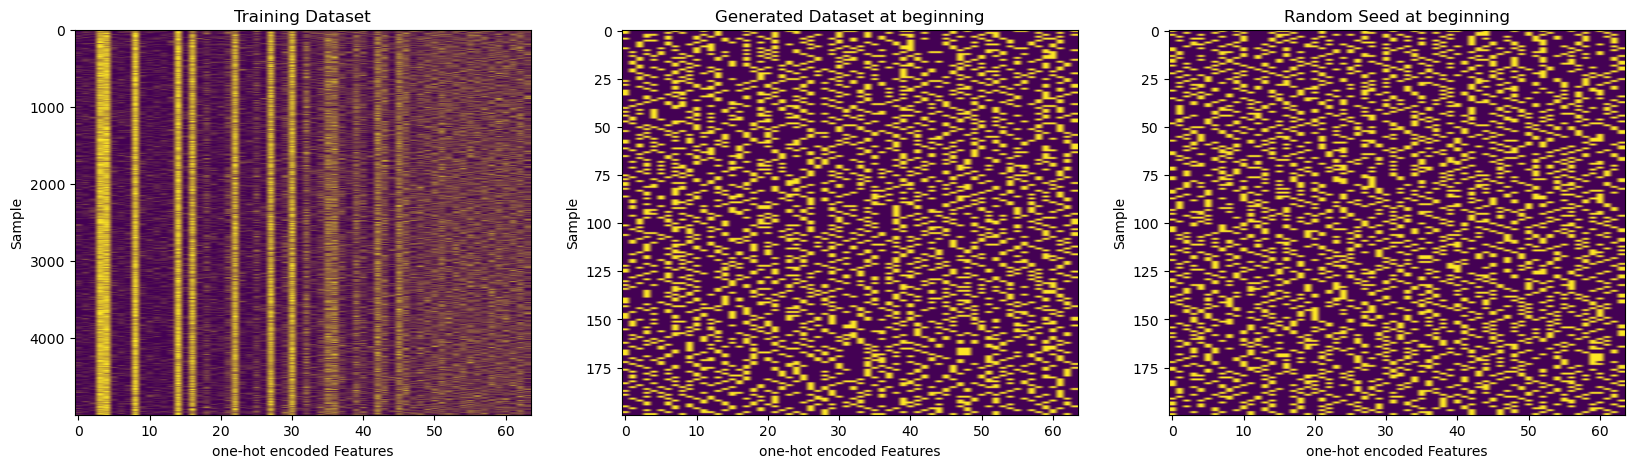

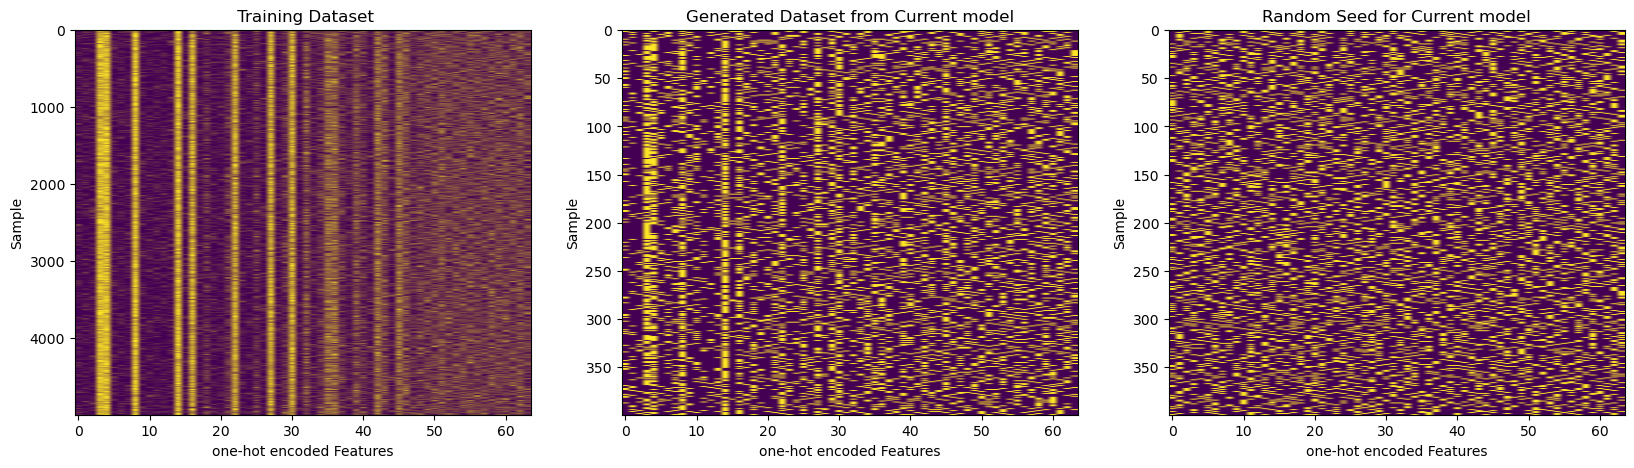

In [76]:
fig, ax = plt.subplots(1,3,figsize=(20,5))
ax[0].imshow(LRBM.unfurled_data, aspect = "auto")
ax[1].imshow(Fin_state_begin,aspect = "auto")
ax[2].imshow(Seed_begin,aspect = "auto")

for i in range(0,3):
    ax[i].set_xlabel("one-hot encoded Features")
    ax[i].set_ylabel("Sample")

ax[0].set_title("Training Dataset")
ax[1].set_title("Generated Dataset at beginning")
ax[2].set_title("Random Seed at beginning")



fig, ax = plt.subplots(1,3,figsize=(20,5))
ax[0].imshow(LRBM.unfurled_data, aspect = "auto")
ax[1].imshow(Fin_state_current,aspect = "auto")
ax[2].imshow(Seed_current,aspect = "auto")

for i in range(0,3):
    ax[i].set_xlabel("one-hot encoded Features")
    ax[i].set_ylabel("Sample")

ax[0].set_title(" Training Dataset")
ax[1].set_title("Generated Dataset from Current model")
ax[2].set_title("Random Seed for Current model")

### We now observe structures similar to training data in the Generated Dataset. 

In [106]:
### ------ For natural or Ground Truth (GT) Data ------

## since triplet calculations are slow, I set it to false here
## set it to true if you want to do them
Perform_triplet_calculation = True
### ----------------------------------------------------



Dataset_1 = Compact_Training_Dataset
# Find the unique alphabets in Training Data
Alphabets = Alphabet_list(Dataset_1)
Num_alphabets = len(Alphabets)

Dataset_2 = One_hot_decoder_Array(np.array(Fin_state_current), Alphabets)

print("Number of unique alphabets=", Num_alphabets)

### One hot encoding Training and generated data

Ohe_dataset_1 = One_hot_encoder_Array(Dataset_1, Alphabets)
Ohe_dataset_2= One_hot_encoder_Array(Dataset_2, Alphabets)

### Integer representation

Int_repr_dataset_1 = Integer_encode_Array(Dataset_1, Alphabets)
Int_repr_dataset_2 = Integer_encode_Array(Dataset_2, Alphabets)

##-----

Sing_Freq_GT= Singlet_Frequency(Ohe_dataset_1, Num_alphabets)
PW_Freq_GT,_ = Pairwise_Frequency(Ohe_dataset_1, Num_alphabets)
PW_Corr_GT,_ = Pairwise_Correlation(Ohe_dataset_1, Num_alphabets)

if Perform_triplet_calculation:
    Trip_Corr_GT =Triplet_Correlation(Int_repr_dataset_1, Ohe_dataset_1, Num_alphabets)
print("Naturals Done")

### ------ For LRBM Data ------
Sing_Freq_LRBM= Singlet_Frequency(Ohe_dataset_2, Num_alphabets)
PW_Freq_LRBM,_ = Pairwise_Frequency(Ohe_dataset_2, Num_alphabets)
PW_Corr_LRBM,_ = Pairwise_Correlation(Ohe_dataset_2, Num_alphabets)
if Perform_triplet_calculation:
    Trip_Corr_LRBM =Triplet_Correlation(Int_repr_dataset_2, Ohe_dataset_2, Num_alphabets)
print("LRBM Done")

Number of unique alphabets= 4
Naturals Done
LRBM Done


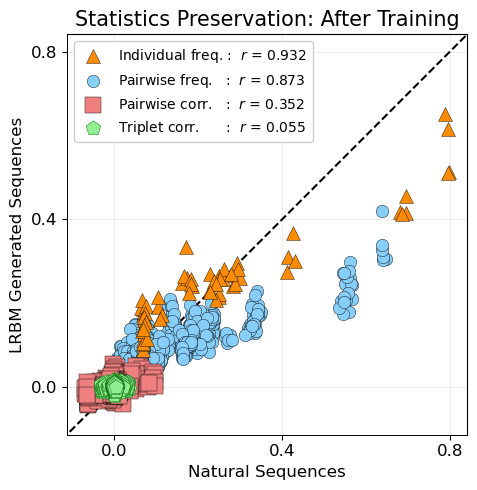

In [107]:

# ----Data  (it could be by partition or whole)-------------


individual_nat  = np.array(Sing_Freq_GT)
individual_syn  = np.array(Sing_Freq_LRBM)

pairwise_freq_nat  = np.array(PW_Freq_GT)
pairwise_freq_syn  = np.array(PW_Freq_LRBM)

pairwise_corr_nat  = np.array(PW_Corr_GT)
pairwise_corr_syn  = np.array(PW_Corr_LRBM)


if Perform_triplet_calculation:
    triplet_nat  = np.array(Trip_Corr_GT)
    triplet_syn  = np.array(Trip_Corr_LRBM)

# ── Plot config ───────────────────────────────────────────────────────

if Perform_triplet_calculation:
    datasets = [
        dict(nat=individual_nat,   syn=individual_syn,
            label='Individual freq. ',  color='darkorange', marker='^', size=100, edgecolor = "black", zorder = 3),
        dict(nat=pairwise_freq_nat, syn=pairwise_freq_syn,
            label='Pairwise freq.   ',    color='lightskyblue', marker='o', size=80, edgecolor = "black", zorder = 2),
        dict(nat=pairwise_corr_nat, syn=pairwise_corr_syn,
            label='Pairwise corr.   ',    color='lightcoral', marker='s', size=125, edgecolor = "black", zorder = 3),
        dict(nat=triplet_nat,       syn=triplet_syn,
            label='Triplet corr.      ',     color='lightgreen', marker='p', size=125, edgecolor = "darkgreen", zorder =3),
    ]

else:
    datasets = [
        dict(nat=individual_nat,   syn=individual_syn,
            label='Individual freq. ',  color='darkorange', marker='^', size=30, edgecolor = "black", zorder = 3),
        dict(nat=pairwise_freq_nat, syn=pairwise_freq_syn,
            label='Pairwise freq.   ',    color='lightskyblue', marker='o', size=30, edgecolor = "black", zorder = 2),
        dict(nat=pairwise_corr_nat, syn=pairwise_corr_syn,
            label='Pairwise corr.   ',    color='lightcoral', marker='s', size=65, edgecolor = "black", zorder = 3)
    ]


for d in datasets:
    r2   = r2_score(d['nat'], d['syn'])
    rmse = np.sqrt(np.mean((d['nat'] - d['syn']) ** 2))
    pson_r= pearsonr(d['nat'], d['syn'])[0]
    d['r2']= r2
    d['rmse']= rmse
    d['pearson_r'] = pson_r

# ── Figure ────────────────────────────────────────────────────────────
fig1, ax = plt.subplots(figsize=(5, 5))

# Determine global axis limits across all datasets
all_nat = np.concatenate([d['nat'] for d in datasets])
all_syn = np.concatenate([d['syn'] for d in datasets])
lo = min(all_nat.min(), all_syn.min())
hi = max(all_nat.max(), all_syn.max())
pad = (hi - lo) * 0.05
lo, hi = lo - pad, hi + pad



# Scatter each statistic + annotation
annotation_y = 0.97  # tracks vertical position of text annotations
for d in datasets:
    
    pson = d['pearson_r']
    label_o = f"{d['label']}:  $r$ = {pson :.3f}"
    ax.scatter(d['nat'], d['syn'],
               color=d['color'], marker=d['marker'],
               s=d['size'], alpha=1, linewidths=0.3,
               edgecolors=d['edgecolor'], zorder=d['zorder'], label=label_o)

    annotation_y -= 0.07

# ── Axes formatting ───────────────────────────────────────────────────
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect('equal')
ax.set_xlabel('Natural Sequences', fontsize=12)
ax.set_ylabel('LRBM Generated Sequences', fontsize=12)
ax.set_title('Statistics Preservation: After Training', fontsize=15)


ax.tick_params(labelsize=10)
ax.grid(linewidth=0.4, alpha=0.4, zorder=0)

ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(True)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(0.7)

# Legend (shapes/colors only, no duplicating the text annotations)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, fontsize=10, frameon=True,
          framealpha=1, edgecolor='#cccccc',
          loc='upper left')
#plt.xlim(-0.2,1)
#plt.ylim(-0.2,1)
# 1:1 diagonal
ax.plot([-0.2, 1], [-0.2, 1], color='black', linewidth=1.5,
        linestyle='--', zorder=1)


ax.set_xticks([0,0.4,0.8])
ax.set_yticks([0,0.4,0.8])
ax.tick_params(labelsize = 12)

plt.tight_layout()


save = False
Fig_path = "../../Plots/"
if save == True:

    plt.savefig(Fig_path+'statistics_preservation_LRBM.pdf', transparent= True, dpi=300, bbox_inches='tight')
    plt.savefig(Fig_path+'statistics_preservation_LRBM.png', dpi=300, bbox_inches='tight')
plt.show()

We observe that post training the frequencies are shifting towards that of Natural sequences

### Before Training:

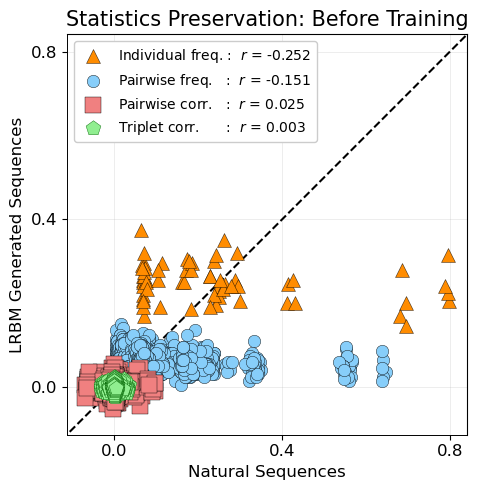

In [113]:
fig0

### After Training:

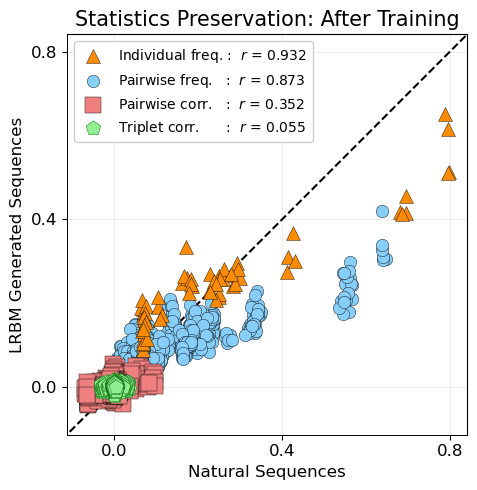

In [114]:
fig1